Imports and config (always run this first)

In [1]:
import os
import numpy as np
from types import SimpleNamespace
import sys
sys.path.append('/mnt/md0/tempFolder/samAnderson/unet-gnn/') 
sys.path.append('/mnt/md0/tempFolder/samAnderson/unet-gnn/functions/')
from config import pathology_config as cfg
from postprocessing import PostProcessor
%load_ext autoreload
%autoreload 2

# Create the postprocessing object
p = PostProcessor(first=cfg.first)

Test the model on ADNIs CN, MCI, and AD cohorts

In [13]:
import torch
from nn_optim_unet import test_nn, gnn_builder

# Load model
model = gnn_builder(feature_sizes=cfg.feature_sizes, dropout_levels=cfg.dropout_levels)
model.load_state_dict(torch.load(cfg.model_weights))

# Loop over cohorts
for name, cohort_cfg in cfg.cohort_dict.items():
    print(f'\n===== ADNI {name} =====\n')

    # Run the cohort through the model
    cohort_fused_cfg = SimpleNamespace(**vars(cohort_cfg), **vars(cfg))
    test_dict = test_nn(model, cohort_fused_cfg)

    raw_lbas, raw_gbags, raw_lbags = p.clip_and_smooth(
        test_dict['predictions'],
        test_dict['targets'],
        medial_present=True
    )

    # Report the MAE across the cortical surface (no medial wall) BEFORE bias correction
    print(f"Updated MAE (L1 Loss): {np.mean(np.abs(raw_lbas - test_dict['targets'][:, None]))}")

    # Run bias correction (use/compute CN factors only)
    if name == 'CN':
        bc_lbags, bc_gbags, bc_lbas, CN_factors = p.bias_correct(
            y_pred=raw_lbas,
            y_true=test_dict['targets']
        )
        # Save the factors
        np.save(f'{cohort_cfg.array_path}CN_factors.npy', CN_factors)
    # shapes: (vertices) ; (subjects) : (subjects, vertices)
    else:
        bc_lbags, bc_gbags, bc_lbas, _ = p.bias_correct(
            y_pred=raw_lbas,
            y_true=test_dict['targets'],
            factors=CN_factors # will break if CN is not first
        )

    # Report the MAE across the cortical surface (no medial wall) AFTER bias correction
    print(f"Bias-Corrected MAE (L1 Loss): {np.mean(np.abs(bc_lbas - test_dict['targets'][:, None]))}")
    del test_dict

    # Save model outputs
    os.makedirs(cohort_cfg.vis_path, exist_ok=True)
    os.makedirs(cohort_cfg.array_path, exist_ok=True)
    
    np.save(f'{cohort_cfg.array_path}raw_lbags.npy', raw_lbags)
    np.save(f'{cohort_cfg.array_path}raw_gbags.npy', raw_gbags)
    np.save(f'{cohort_cfg.array_path}raw_lbas.npy', raw_lbas)

    np.save(f'{cohort_cfg.array_path}bc_lbags.npy', bc_lbags)
    np.save(f'{cohort_cfg.array_path}bc_gbags.npy', bc_gbags)
    np.save(f'{cohort_cfg.array_path}bc_lbas.npy', bc_lbas)

    # Create GBAG plots
    cfg.gbag_kde({f'ADNI_{name}_raw' : raw_gbags}, save_to=f'{cohort_cfg.vis_path}raw_gbags');
    cfg.gbag_kde({f'ADNI_{name}_bc' : bc_gbags}, save_to=f'{cohort_cfg.vis_path}bc_gbags');

    # Create LBAG plots (avg across subjects)
    p.generate_cortical_plot(raw_lbags.mean(axis=0), save_to=f'{cohort_cfg.vis_path}raw_lbags', medial_present=False);
    p.generate_cortical_plot(bc_lbags.mean(axis=0), save_to=f'{cohort_cfg.vis_path}bc_lbags', medial_present=False);

    # Clean up variables from current cohort
    del bc_lbags, bc_gbags, bc_lbas
    del raw_lbags, raw_gbags, raw_lbas

# Clean up model
del model


===== ADNI CN =====

MAE (L1) Loss: 6.354 across 1128 observations
Updated MAE (L1 Loss): 5.630906864418499
Factors: [-0.75039412 53.31793182]
Bias-Corrected MAE (L1 Loss): 2.811911158626424

===== ADNI MCI =====

MAE (L1) Loss: 6.431 across 366 observations
Updated MAE (L1 Loss): 5.794344375317474
Bias-Corrected MAE (L1 Loss): 2.680194219119656

===== ADNI AD =====

MAE (L1) Loss: 7.562 across 477 observations
Updated MAE (L1 Loss): 6.983618908010095
Bias-Corrected MAE (L1 Loss): 3.146909041189397


Display the GBAGs of the CN, MCI, and AD sets in a single KDE

Mean GBAG for CNs: -0.00
Mean GBAG for MCIs: 0.57
Mean GBAG for ADs: 1.09


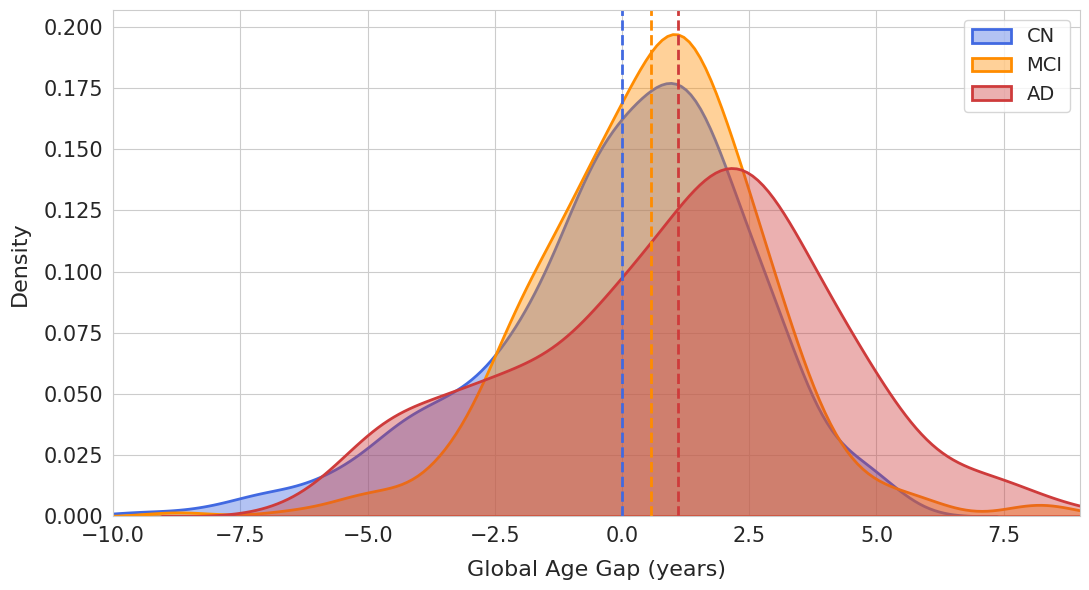

In [40]:
from IPython.display import Image, display

cohorts = {
    'CN' : np.load(f"{cfg.cohort_dict['CN'].array_path}bc_gbags.npy"),
    'MCI' : np.load(f"{cfg.cohort_dict['MCI'].array_path}bc_gbags.npy"),
    'AD' : np.load(f"{cfg.cohort_dict['AD'].array_path}bc_gbags.npy")
}

os.makedirs(f'{cfg.cross_cohort_path}all/visualizations/', exist_ok=True)
save_path = f'{cfg.cross_cohort_path}all/visualizations/cn-mci-ad_gbags.png'
cfg.gbag_kde(cohorts, save_to=save_path, return_plot=True)

print(f"Mean GBAG for CNs: {np.mean(cohorts['CN']):.2f}")
print(f"Mean GBAG for MCIs: {np.mean(cohorts['MCI']):.2f}")
print(f"Mean GBAG for ADs: {np.mean(cohorts['AD']):.2f}")

Visualize differences in cohort LBAGs

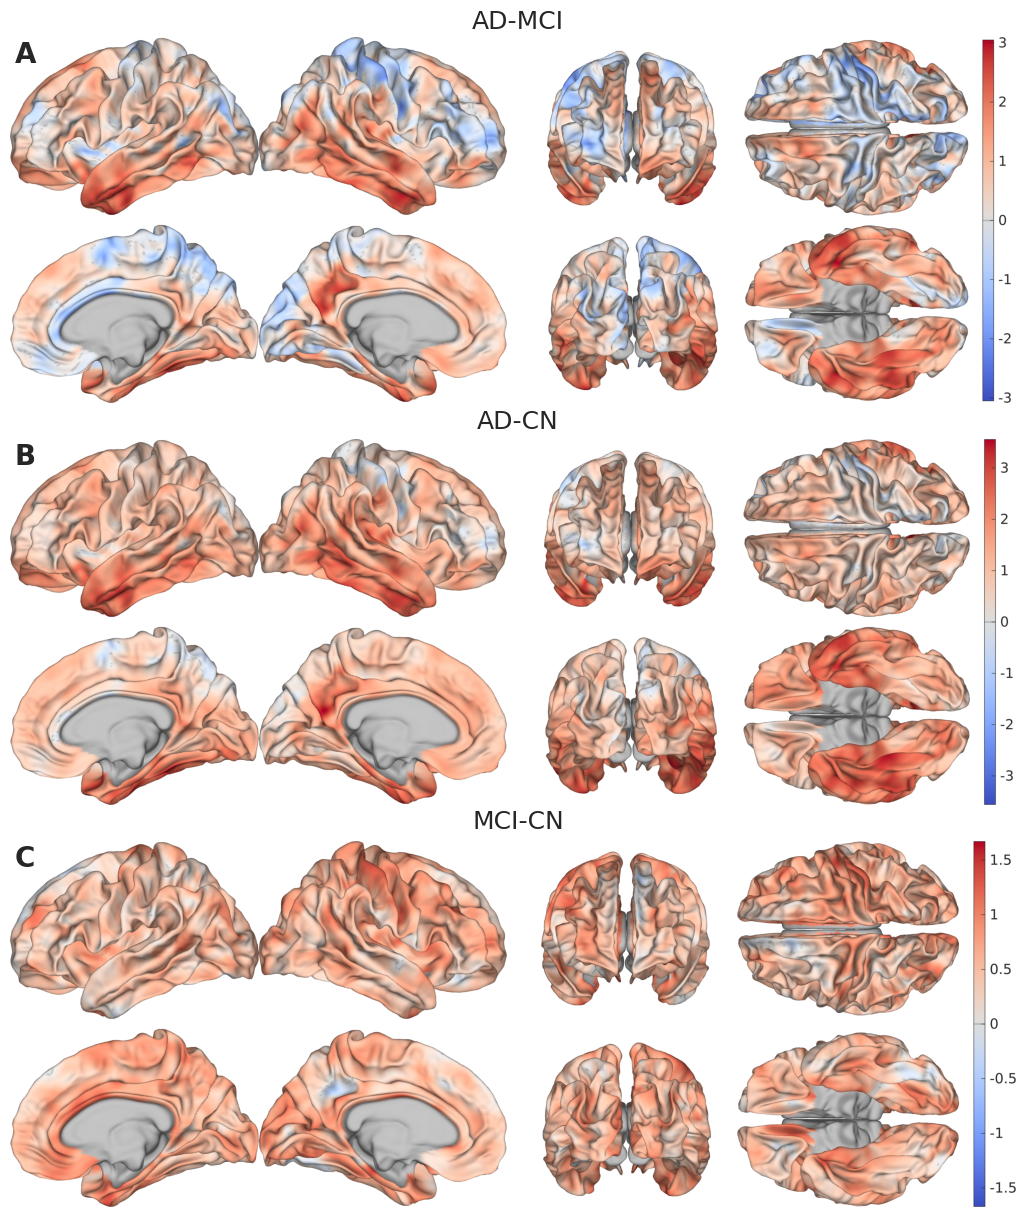

In [41]:
# Define hierarchy (higher - lower)
hierarchy = ['AD', 'MCI', 'CN']

# Build LBAG dict
lbag_dict = {}
for name, cohort_cfg in cfg.cohort_dict.items():
    bc_lbags = np.load(f'{cohort_cfg.array_path}bc_lbags.npy')
    lbag_dict[name] = bc_lbags

# Order cohorts by hierarchy (filter to those present)
ordered = [c for c in hierarchy if c in lbag_dict]

paths = []

# Compute pairwise differences
for i in range(len(ordered)):
    for j in range(i + 1, len(ordered)):

        name0 = ordered[i]
        name1 = ordered[j]

        lbag0 = lbag_dict[name0]
        lbag1 = lbag_dict[name1]

        comparison_name = f'{name0}-{name1}'
        cohort_vis_path = f'{cfg.cross_cohort_path}{comparison_name}/visualizations/'
        cohort_array_path = f'{cfg.cross_cohort_path}{comparison_name}/arrays/'

        # Create folder for output
        os.makedirs(cohort_vis_path, exist_ok=True)
        os.makedirs(cohort_array_path, exist_ok=True)

        # Compute diff, generate cortical plot, and save
        lbag_diff_map = lbag0.mean(axis=0) - lbag1.mean(axis=0)
        
        np.save(f'{cohort_array_path}lbag_diff.npy', lbag_diff_map)
        comparison_plot_path = f'{cohort_vis_path}lbag_diff'
        p.generate_cortical_plot(
            lbag_diff_map,
            medial_present=False,
            save_to=comparison_plot_path
        )

        # Add plot path to list for visualization
        paths.append((comparison_name, comparison_plot_path))

# Convert to plotting format
plot_paths = []
plot_titles = []

for name, base_path in paths:
    plot_paths.append(f'{base_path}_latL_latR_medR_medL.png')
    plot_paths.append(f'{base_path}_ant_dor_pos_ven.png')
    plot_titles.append(name)

# Plot
cfg.plot_brain_pairs(
    plot_paths,
    plot_titles=plot_titles
)

Get network and region-level LBAGs and LBAG differences for CNs, MCIs, and ADs | AD-CN, AD-MCI, and MCI-CN

In [2]:
# Load LBAGs
lbags = {
    label: np.load(f'{c.array_path}bc_lbags.npy').mean(axis=0)
    for label, c in cfg.cohort_dict.items()
}

# Define differences
diff_pairs = {
    'AD-CN': ('AD', 'CN'),
    'AD-MCI': ('AD', 'MCI'),
    'MCI-CN': ('MCI', 'CN')
}

# Build tables
df_region = cfg.build_location_df(
    lbags, p,
    per='region',
    medial_present=False,
    add_diffs=True,
    diff_pairs=diff_pairs
)

df_network = cfg.build_location_df(
    lbags, p,
    per='network',
    medial_present=False,
    add_diffs=True,
    diff_pairs=diff_pairs
)

# Build region to lobe mapping
region_to_lobe = {
    region: lobe
    for lobe, regions in cfg.region_to_lobe_dict.items()
    for region in regions
}

# Map regions to lobes
df_lobe = df_region.copy()
df_lobe['lobe'] = df_lobe['region'].map(region_to_lobe)
df_lobe = df_lobe.dropna(subset=['lobe'])
df_lobe = df_lobe.groupby('lobe').mean(numeric_only=True).reset_index()

# Ensure output directory exists
out_dir = f'{cfg.cross_cohort_path}all/arrays/'
os.makedirs(out_dir, exist_ok=True)

# Save dfs
df_region.to_csv(f'{out_dir}LBAGs_region.csv')
df_lobe.to_csv(f'{out_dir}LBAGs_lobe.csv')
df_network.to_csv(f'{out_dir}LBAGs_network.csv')